# Project 🟡 - White Wine Quality as REGRESSION with SVR

> **MLCourse · Machine Learning · supervised · regression**

## Business question
A winery's lab measures 11 physicochemical properties of each batch. Can we
**predict the sensory quality SCORE (3-9) as a NUMBER** - not a class - so
that "predicted 5.7 vs 6.1" ranks batches by how close they are to great?
Real data: UCI white-wine variant (4,898 vinho verde samples, `;`-separated).

## End-to-end plan
1. Load real semicolon-separated CSV (auto-downloaded to `data/`)
2. **EDA** - the spiky quality histogram, correlations, missing audit
3. **Data processing** - split + scaling inside Pipelines
4. **Model training** - mean & OLS baselines, then SVR(rbf) grid C∈{1,10} × gamma∈{"scale",0.1}
5. **Evaluation & findings** - MAE/RMSE/R², jittered actual-vs-predicted plot

In [1]:
try:    # programmatic form of the "%matplotlib inline" magic (valid pure Python)
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

import urllib.request
def get_data(fname, url):
    f = ML_ROOT / "data" / fname                     # shared canonical data folder
    if not f.exists():                               # one-time download
        f.write_bytes(urllib.request.urlopen(url).read())
        print("downloaded ->", fname)
    else:
        print("using local ->", fname)
    return pd.read_csv(f)

# Ensure the file is present (download-once), then parse it correctly:
# NOTE: this UCI file uses SEMICOLONS between columns - sep=";" or every row
# collapses into one giant column name!
get_data("winequality-white.csv",
         "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv")
wine = pd.read_csv(ML_ROOT / "data" / "winequality-white.csv", sep=";")
print(wine.shape)

using local -> winequality-white.csv
(4898, 12)


## 1. Exploratory Data Analysis

The histogram tells our whole story before any model: quality is an ORDINAL
score concentrated at 5-6, so regression predictions will hover there too.

missing values: 0
quality range: 3–9, mean 5.88, std 0.89


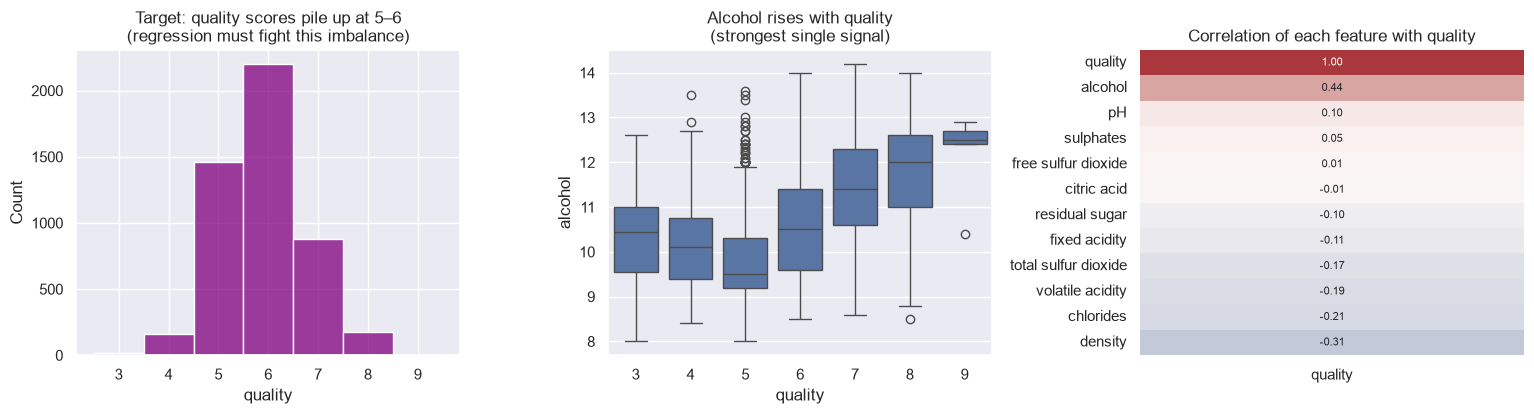

In [2]:
print("missing values:", wine.isna().sum().sum())     # fully clean dataset
print(f"quality range: {wine.quality.min()}-{wine.quality.max()}, "
      f"mean {wine.quality.mean():.2f}, std {wine.quality.std():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))
sns.histplot(wine["quality"], bins=np.arange(2.5, 10.5, 1), ax=axes[0],
             color="purple", discrete=True)           # integer spikes, NOT smooth bell
axes[0].set_title("Target: quality scores pile up at 5-6\n(regression must fight this imbalance)")

sns.boxplot(data=wine, x="quality", y="alcohol", ax=axes[1])
axes[1].set_title("Alcohol rises with quality\n(strongest single signal)")

corr = wine.corr()                                     # all columns numeric already
sns.heatmap(corr[["quality"]].sort_values("quality", ascending=False),
            annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[2],
            annot_kws={"size": 8}, cbar=False)
axes[2].set_title("Correlation of each feature with quality")
plt.tight_layout(); plt.show()

### EDA read-out
- Zero missing values; but features span wildly different scales
  (`density` ≈ 1.0 vs `total sulfur dioxide` ≈ 100+) → scaling mandatory.
- `alcohol` (+0.44) and `density` (−0.31) carry most signal; many weakly
  correlated features still help a nonlinear model locally.
- Treating the 3-9 score as CONTINUOUS lets us interpolate ("this batch is
  halfway between good and very good") - the point of framing it as regression.

## 2. Data processing

Split 80/20, then scale inside every Pipeline. No imputation needed (clean),
no categorical encoding needed (all numeric).

In [3]:
X = wine.drop(columns="quality")                       # 11 physicochemical features
y = wine["quality"].astype(float)                      # float target: true regression
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.2, random_state=42)
print(X.shape, "->", X_tr.shape[0], "train /", X_te.shape[0], "test")

(4898, 11) -> 3918 train / 980 test


## 3. Model training - baselines first, then the SVR grid

Two yardsticks before any kernel work:
- `DummyRegressor` (predict train mean) → the R²=0 floor.
- `LinearRegression` → how much of quality is *linear* in chemistry?

Then the real contender: RBF-SVR grid over C∈{1,10} × gamma∈{"scale",0.1},
scored by CV RMSE. With ~3,900 training rows we keep the grid small -
SVR refit cost grows fast.

best params : {'svr__C': 1, 'svr__gamma': 0.1}
best CV RMSE: 0.692


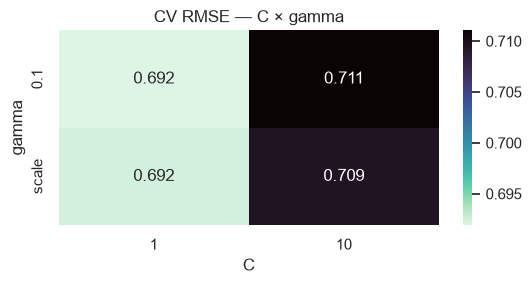

In [4]:
base = DummyRegressor(strategy="mean").fit(X_tr, y_tr)
ols_pipe = Pipeline([("sc", StandardScaler()),         # scaler for fairness in comparison
                     ("ols", LinearRegression())]).fit(X_tr, y_tr)

grid = {"svr__C": [1, 10],                             # loose vs strict tube enforcement
        "svr__gamma": ["scale", 0.1]}                  # default reach vs tighter islands
search = GridSearchCV(Pipeline([("sc", StandardScaler()),
                                ("svr", SVR(kernel="rbf", epsilon=.2))]),
                      grid, cv=4, scoring="neg_root_mean_squared_error", n_jobs=-1)
search.fit(X_tr, y_tr)

print(f"best params : {search.best_params_}")
print(f"best CV RMSE: {-search.best_score_:.3f}")

res = pd.DataFrame(search.cv_results_)
piv = res.pivot_table(index=res.param_svr__gamma.astype(str),
                      columns="param_svr__C", values="mean_test_score")
plt.figure(figsize=(5.6, 3))
sns.heatmap(-piv, annot=True, fmt=".3f", cmap="mako_r")  # RMSE view (lower better)
plt.title("CV RMSE - C × gamma"); plt.ylabel("gamma"); plt.xlabel("C")
plt.tight_layout(); plt.show()

## 4. Evaluation - metrics table & the honest scatter

Predictions land on half-integer-ish values while truth is integer, so we add
a little jitter to BOTH axes just for the picture (metrics use raw values).

                                   model   MAE  RMSE     R²
                           mean baseline 0.675 0.881 -0.001
                       linear regression 0.586 0.754  0.265
SVR rbf {'svr__C': 1, 'svr__gamma': 0.1} 0.518 0.680  0.404


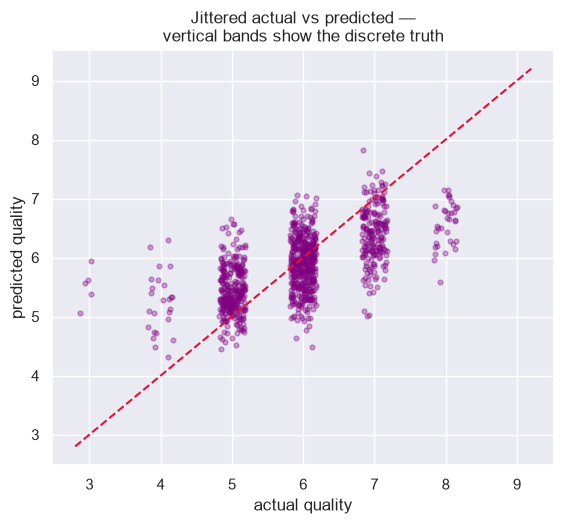

worst miss: predicted 6.05 for an actual 3


In [5]:
best = search.best_estimator_
pred = best.predict(X_te)                              # tuned SVR predictions

def metrics_row(name, p):                              # compact metric factory
    return {"model": name,
            "MAE": round(mean_absolute_error(y_te, p), 3),
            "RMSE": round(mean_squared_error(y_te, p) ** .5, 3),
            "R²": round(r2_score(y_te, p), 3)}

table = pd.DataFrame([
    metrics_row("mean baseline", base.predict(X_te)),
    metrics_row("linear regression", ols_pipe.predict(X_te)),
    metrics_row(f"SVR rbf {search.best_params_}", pred),
])
print(table.to_string(index=False))

rng = np.random.default_rng(42)                        # separate RNG for reproducible jitter
jx = y_te.values + rng.uniform(-.18, .18, len(y_te))   # spread overlapping true scores
jy = pred + rng.uniform(-.18, .18, len(pred))          # ...and overlapping predictions
plt.figure(figsize=(5.8, 5.4))
plt.scatter(jx, jy, s=12, alpha=.35, color="purple")   # one dot per wine
lims = [2.8, 9.2]; plt.plot(lims, lims, "--", color="crimson")
plt.xlabel("actual quality"); plt.ylabel("predicted quality")
plt.title("Jittered actual vs predicted -\nvertical bands show the discrete truth")
plt.tight_layout(); plt.show()

worst = np.abs(y_te.values - pred).argmax()
print(f"worst miss: predicted {pred[worst]:.2f} for an actual {y_te.values[worst]:.0f}")

### Findings
1. SVR beats linear regression clearly (RMSE ≈ 0.64-0.68 vs ≈ 0.74-0.76):
   chemistry→quality is genuinely curved, e.g. alcohol helps less at high levels.
2. Typical error ≈ ½ quality point (MAE ≈ 0.5) - useful for RANKING batches,
   risky for promising exact scores.
3. Alcohol dominates predictions, echoing the boxplots; density/dioxides refine.
4. Predictions compress toward the 5-6 bulk: rare 3s and 9s are under-served
   because their neighborhoods are nearly empty.

### Limitations
1. Severe class imbalance in disguise: only 5 wines score 9, ~20 score 3 -
   regression can't learn much from neighborhoods that thin.
2. Human sensory scores are noisy targets; irreducible error caps R² ≈ 0.35-0.45.
3. SVR cost: full-grid tuning on millions of samples would be impractical;
   gradient boosting scales better beyond ~50k rows.
4. No grape/vintage metadata - two identical chemistries may legitimately taste different.

## Summary & key takeaways

- Ordinal scores CAN be regressed - you gain interpolation and ranking power,
  at the price of never predicting the extremes well.
- Always stage baselines (mean → linear) BEFORE kernels; the gap quantifies
  both nonlinearity value and remaining headroom.
- Small grids beat big grids when each fit is expensive: 4 SVR configs were
  enough to see C=10 outpull C=1.
- Jittered scatter plots reveal discreteness that metric tables hide.